# X/Y MOD 输入零输出偏置测量

固定 X/Y 载波幅度（可分别设置），在 AM DC=0 附近精细扫描 DC 电压，正弦拟合提取幅值，
线性回归找 Amp=0 对应的 DC 偏置点。X 和 Y 的 MOD 输入可独立控制。

## 实验设计

- **X 载波**: 固定幅值 (可配置), AM EXT, 扫描 MOD DC
- **Y 载波**: 固定幅值 (可配置), AM EXT, 扫描 MOD DC
- **扫描范围**: DC = -0.2V → +0.2V, 精细步进
- **检测方式**: SDS 示波器 C2(X)/C3(Y) 正弦拟合提取幅值

## 硬件连接

| 信号 | 仪器 | 通道 | 说明 |
|------|------|------|------|
| X 载波 | DG4000 (dg_comp) | CH1 | 90kHz 正弦 + AM EXT → 示波器 CH2 |
| Y 载波 | DG4000 (dg_comp) | CH2 | 90kHz 正弦 + AM EXT → 示波器 CH3 |
| X AM DC | DG4000 (dg_am) | CH1 | DC → dg_comp CH1 MOD Input |
| Y AM DC | DG4000 (dg_am) | CH2 | DC → dg_comp CH2 MOD Input |
| 示波器 | SDS | C2, C3 | 直接测输出电压 |

## 目录

1. [环境准备与参数配置](#env) — 库导入、设备映射、实验参数
2. [设备连接与 AM 配置](#setup) — 连接设备、固定载波、AM EXT 调制
3. [DC 扫描与波形采集](#acq) — 扫描 MOD DC 电压、逐点保存波形
4. [正弦拟合 + 零输出点查找](#analysis) — 拟合幅值、线性回归找零点
5. [结果可视化](#viz) — Amp vs DC 散点 + 拟合线
6. [安全关闭](#cleanup)

<a id='env'></a>
## 1. 环境准备与参数配置

导入库、加载设备映射、定义实验参数。

In [11]:
# ========== 交互式绘图 ==========
%matplotlib widget

from pathlib import Path
import sys
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display

from signal_generator import DG4000Instrument
from sds_acquisition import SDSInstrument, SDSAcquisition, AcquisitionConfig, ChannelConfig
from lockin_amplifier import (
    HF2Instrument,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod,
)
from scipy.optimize import curve_fit
from tqdm import tqdm
EXPERIMENT_TYPE = "XY_MOD_ZeroOffset"
PURPOSE = "mod_zero_offset"

print("所有库导入成功")

所有库导入成功


In [12]:
# 加载映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# ============================================================
# ========== 实验参数 ==========
# ============================================================

# ---- X/Y 载波参数 (可分别设置) ----
XY_CARRIER_FREQ = 90e3        # 载波频率 (Hz)
XY_AM_DEPTH = 100             # AM 调制深度 (%)
X_CARRIER_AMPLITUDE = 10.0    # X 载波幅值 (Vpp)
Y_CARRIER_AMPLITUDE = 10.08    # Y 载波幅值 (Vpp)

# ---- MOD DC 电压扫描 (dg_am CH1→X MOD, CH2→Y MOD, 同步扫描) ----
DC_SCAN_MIN = -0.50           # 扫描下限 (V)
DC_SCAN_MAX = +2.5         # 扫描上限 (V)
DC_SCAN_STEPS = 3001            # 点数 (奇数, 保证含 0V)

DC_SETTLE_TIME = 0.05         # DC 电压切换稳定时间 (s)

# ---- 示波器参数 ----
SCOPE_SAMPLING_RATE = 500e3   # 500 kSa/s
SCOPE_TIME_WINDOW = 0.001     # 2 ms 窗口
SCOPE_CH_X = 2                # 示波器通道: X → C2
SCOPE_CH_Y = 3                # 示波器通道: Y → C3
SCOPE_VOLT_SCALE = 0.4        # V/div (小信号用低档位)

# ---- 运行目录 ----
RUN_TAG = "zero_offset"

DC_VOLTAGES = np.linspace(DC_SCAN_MIN, DC_SCAN_MAX, DC_SCAN_STEPS)

n_dc = len(DC_VOLTAGES)
print(f"  X 载波: {X_CARRIER_AMPLITUDE} Vpp, Y 载波: {Y_CARRIER_AMPLITUDE} Vpp, {XY_CARRIER_FREQ/1e3:.0f}kHz")
print(f"  MOD DC 扫描: {DC_SCAN_MIN:.2f}→{DC_SCAN_MAX:.2f} V, {n_dc} 点")
print(f"  示波器: C{SCOPE_CH_X}(X), C{SCOPE_CH_Y}(Y), {SCOPE_SAMPLING_RATE/1e3:.0f}kSa/s, {SCOPE_VOLT_SCALE}V/div")

  X 载波: 10.0 Vpp, Y 载波: 10.08 Vpp, 90kHz
  MOD DC 扫描: -0.50→2.50 V, 3001 点
  示波器: C2(X), C3(Y), 500kSa/s, 0.4V/div


<a id='setup'></a>
## 2. 设备连接与 AM 配置

连接 dg_comp（载波）、dg_am（MOD DC）、SDS 示波器，设置固定载波和 AM EXT 调制。

In [13]:
devices = {}

try:

    # ---- DG4000: X/Y 载波 (dg_comp) ----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"dg_comp 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    devices["dg_comp"] = dg_comp

    # ---- DG4000: Z 磁场 + AM DC 控制 (dg_sweep) ----
    dg_sweep_cfg = MAPPING["Z_magnetic_field"]
    dg_sweep = DG4000Instrument(dg_sweep_cfg["resource"], channel=1)
    dg_sweep.connect()
    print(f"dg_sweep 已连接: {dg_sweep.idn()}")
    dg_sweep.set_ref_clock_source("EXTernal")
    dg_sweep.setup_dc(0.0, channel=1)
    dg_sweep.set_output(False, channel=1)
    dg_sweep.set_output(False, channel=2)
    print(f"  -> CH1 (Z 场): OFF; CH2 (AM DC): OFF")
    devices["dg_sweep"] = dg_sweep

    # ---- DG4000: Pump 调制 (dg_mod) ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"dg_mod 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 (dg_temp) ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"dg_temp 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- DG4000: 光功率 (dg_laser) ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"dg_laser 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

    # ---- DG4000: X/Y AM DC 独立控制 (dg_am) ----
    dg_am_cfg = MAPPING["X_magnetic_field_AM"]
    dg_am = DG4000Instrument(dg_am_cfg["resource"], channel=1)
    dg_am.connect()
    print(f"dg_am 已连接: {dg_am.idn()}")
    dg_am.set_ref_clock_source("EXTernal")
    # CH1 → X MOD, CH2 → Y MOD (独立!)
    dg_am.setup_dc(0.0, channel=1)
    dg_am.setup_dc(0.0, channel=2)
    dg_am.set_output(False, channel=1)
    dg_am.set_output(False, channel=2)
    devices["dg_am"] = dg_am

    # ---- SDS 示波器 ----
    scope_cfg = MAPPING.get("scope_waveform", {})
    scope_resource = scope_cfg.get("resource", "")
    scope = SDSInstrument(scope_resource)
    scope.connect()
    print(f"示波器已连接: {scope.idn()}")
    devices["scope"] = scope

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

dg_comp 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
dg_sweep 已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
  -> CH1 (Z 场): OFF; CH2 (AM DC): OFF
dg_mod 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
dg_temp 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
dg_laser 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q280100002,00.02.01.00.02
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部
dg_am 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14
示波器已连接: Siglent Technologies,SDS1204X HD,SDSEV82X900704,6.9.12.1.1.3.8

所有设备连接完成，共 8 个设备


In [14]:
dg_am = devices["dg_am"]
scope = devices["scope"]

# ---- 创建运行目录 ----
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ---- 保存配置 ----
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "x_carrier_amplitude_Vpp": X_CARRIER_AMPLITUDE,
    "y_carrier_amplitude_Vpp": Y_CARRIER_AMPLITUDE,
    "xy_carrier_freq_Hz": XY_CARRIER_FREQ,
    "am_depth_pct": XY_AM_DEPTH,
    "dc_scan_min_V": DC_SCAN_MIN,
    "dc_scan_max_V": DC_SCAN_MAX,
    "dc_scan_steps": DC_SCAN_STEPS,
    "scope": {
        "sampling_rate_Hz": SCOPE_SAMPLING_RATE,
        "time_window_s": SCOPE_TIME_WINDOW,
        "ch_x": SCOPE_CH_X,
        "ch_y": SCOPE_CH_Y,
        "volt_scale_V_per_div": SCOPE_VOLT_SCALE,
    },
}
with open(run_dir / "experiment_config.yaml", "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print("配置已保存")

print(f"配置 AM 外部调制: X={X_CARRIER_AMPLITUDE}Vpp, Y={Y_CARRIER_AMPLITUDE}Vpp, 深度{XY_AM_DEPTH}%")

dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=X_CARRIER_AMPLITUDE, phase=0.0, channel=1)
dg_comp.set_mod_type("AM", channel=1)
dg_comp.set_mod_am_source("EXT", channel=1)
dg_comp.set_mod_am_depth(XY_AM_DEPTH, channel=1)
dg_comp.set_mod_state(True, channel=1)
dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=Y_CARRIER_AMPLITUDE, phase=0.0, channel=2)
dg_comp.set_mod_type("AM", channel=2)
dg_comp.set_mod_am_source("EXT", channel=2)
dg_comp.set_mod_am_depth(XY_AM_DEPTH, channel=2)
dg_comp.set_mod_state(True, channel=2)

dg_comp.set_output(True, channel=1)
print(f"dg_comp CH1: AM EXT {XY_CARRIER_FREQ/1e3:.0f}kHz, 载波{X_CARRIER_AMPLITUDE}Vpp")
print(f"dg_comp CH2: AM EXT {XY_CARRIER_FREQ/1e3:.0f}kHz, 载波{Y_CARRIER_AMPLITUDE}Vpp")

# ---- dg_am: MOD DC 初始置 0V ----
dg_am.setup_dc(0.0, channel=1)
dg_am.setup_dc(0.0, channel=2)
dg_am.set_output(True, channel=1)
dg_am.set_output(True, channel=2)

print(f"dg_am CH1/CH2: DC 0V → MOD Input\n")
print(f"dg_am CH1/CH2: DC 0V → MOD Input\n")

运行目录: d:\Code\exp_agent\data\XY_MOD_ZeroOffset\0522_1253_zero_offset
配置已保存
配置 AM 外部调制: X=10.0Vpp, Y=10.08Vpp, 深度100%
dg_comp CH1: AM EXT 90kHz, 载波10.0Vpp
dg_comp CH2: AM EXT 90kHz, 载波10.08Vpp
dg_am CH1/CH2: DC 0V → MOD Input

dg_am CH1/CH2: DC 0V → MOD Input



<a id='acq'></a>
## 3. DC 扫描与波形采集

扫描 MOD DC 电压，自适应调整示波器垂直档位（40%-90% 满格范围），逐点保存 `.npy`。

In [15]:
# ============================================================
# MOD DC 扫描 — 逐点保存原始波形 + 自适应垂直档位
# ============================================================
print("=" * 60)
print("MOD DC 零输出点扫描开始 (自适应档位)")
print("=" * 60)

# 示波器基础配置 (scale 动态调整)
scope_cfg = AcquisitionConfig()
scope_cfg.sampling_rate = SCOPE_SAMPLING_RATE
scope_cfg.sampling_time = SCOPE_TIME_WINDOW
scope_cfg.acquire_delay = 0.3
scope_cfg.channels = [
    ChannelConfig(number=SCOPE_CH_X, enabled=True, scale=SCOPE_VOLT_SCALE, coupling="DC"),
    ChannelConfig(number=SCOPE_CH_Y, enabled=True, scale=SCOPE_VOLT_SCALE, coupling="DC"),
]
scope_cfg.trigger.mode = "AUTO"
scope_cfg.trigger.source = f"C{SCOPE_CH_X}"

acq = SDSAcquisition(scope)

n_dc_data = len(DC_VOLTAGES)
t_start = time.time()
time_axis_saved = False
VERT_DIVS = 4                       # 有效显示格数
SCALE_MIN = 0.02                    # 最小 V/div
scale_x_used = np.full(n_dc_data, np.nan)   # 记录每点实际使用的 scale
scale_y_used = np.full_like(scale_x_used, np.nan)

pbar = tqdm(total=n_dc_data, desc="采集波形", unit="pt")

try:
    for i_dc, dc_v in enumerate(DC_VOLTAGES):
        dg_am.setup_dc(dc_v, channel=1)
        dg_am.setup_dc(dc_v, channel=2)
        time.sleep(DC_SETTLE_TIME)

        file_tag = f"D{i_dc:02d}"
        scope_scale_x = scope_cfg.channels[0].scale
        scope_scale_y = scope_cfg.channels[1].scale

        # 自适应缩放: 最多重试 2 次
        for retry in range(3):
            try:
                results = acq.acquire_all(scope_cfg)
                if not results or len(results) < 2:
                    break

                x_wave = results[0].voltage
                y_wave = results[1].voltage
                t_wave = results[0].time

                abs_max_x = np.max(np.abs(x_wave))
                abs_max_y = np.max(np.abs(y_wave))
                full_scale_x = scope_scale_x * VERT_DIVS
                full_scale_y = scope_scale_y * VERT_DIVS

                # 判断是否需要缩放 (以两通道中较大的为准)
                need_retry = False

                # 信号太小 (< 40% 满格)
                if abs_max_x < 0.4 * full_scale_x and scope_scale_x > SCALE_MIN * 2:
                    scope_scale_x /= 2
                    scope_cfg.channels[0].scale = scope_scale_x
                    need_retry = True
                if abs_max_y < 0.4 * full_scale_y and scope_scale_y > SCALE_MIN * 2:
                    scope_scale_y /= 2
                    scope_cfg.channels[1].scale = scope_scale_y
                    need_retry = True

                # 信号太大 (> 90% 满格, 可能削顶)
                if abs_max_x > 0.9 * full_scale_x:
                    scope_scale_x *= 2
                    scope_cfg.channels[0].scale = scope_scale_x
                    need_retry = True
                if abs_max_y > 0.9 * full_scale_y:
                    scope_scale_y *= 2
                    scope_cfg.channels[1].scale = scope_scale_y
                    need_retry = True

                if need_retry and retry < 2:
                    tqdm.write(f"  DC={dc_v:.3f}V: 缩放 retry{retry+1} "
                               f"(X→{scope_scale_x:.2f}V/div, Y→{scope_scale_y:.2f}V/div)")
                    continue  # 重采

                # 通过, 保存
                np.save(raw_dir / f"waveform_x_{file_tag}.npy", x_wave)
                np.save(raw_dir / f"waveform_y_{file_tag}.npy", y_wave)
                scale_x_used[i_dc] = scope_scale_x
                scale_y_used[i_dc] = scope_scale_y

                if not time_axis_saved:
                    np.save(raw_dir / "time_axis.npy", t_wave)
                    time_axis_saved = True

                break  # 成功, 跳出 retry 循环

            except Exception as e:
                tqdm.write(f"  scope error @ DC={dc_v:.3f}V: {e}")
                break

        pbar.update(1)
        pbar.set_postfix(DC=f"{dc_v:.3f}", Xdiv=f"{scope_scale_x:.2f}", Ydiv=f"{scope_scale_y:.2f}")

except KeyboardInterrupt:
    tqdm.write(f"\n⚠ 用户中断扫描")
except Exception as e:
    tqdm.write(f"\n扫描出错: {e}")
    raise
finally:
    pbar.close()

elapsed = time.time() - t_start
print(f"\n扫描完成! {n_dc_data} 点, 用时 {elapsed:.0f}s ({elapsed/n_dc_data:.2f}s/点)")

# ---- 保存扫描参数 (含自适应 scale 记录) ----
np.savez(raw_dir / "scan_params.npz",
         dc_voltages=DC_VOLTAGES,
         x_carrier_amplitude=X_CARRIER_AMPLITUDE,
         y_carrier_amplitude=Y_CARRIER_AMPLITUDE,
         xy_carrier_freq=XY_CARRIER_FREQ,
         scale_x_used=scale_x_used,
         scale_y_used=scale_y_used)
print(f"原始波形已保存至: {raw_dir}")

MOD DC 零输出点扫描开始 (自适应档位)


采集波形:   1%|          | 26/3001 [00:16<30:43,  1.61pt/s, DC=-0.475, Xdiv=0.40, Ydiv=0.40]    

  DC=-0.474V: 缩放 retry1 (X→0.20V/div, Y→0.40V/div)


采集波形:   2%|▏         | 60/3001 [00:38<30:16,  1.62pt/s, DC=-0.441, Xdiv=0.20, Ydiv=0.40]    

  DC=-0.440V: 缩放 retry1 (X→0.20V/div, Y→0.20V/div)


...

  DC=1.355V: 缩放 retry1 (X→1.60V/div, Y→0.80V/div)


采集波形:  62%|██████▏   | 1871/3001 [19:25<11:27,  1.64pt/s, DC=1.370, Xdiv=1.60, Ydiv=0.80]    

  DC=1.371V: 缩放 retry1 (X→1.60V/div, Y→1.60V/div)


采集波形: 100%|██████████| 3001/3001 [31:01<00:00,  1.61pt/s, DC=2.500, Xdiv=1.60, Ydiv=1.60]


扫描完成! 3001 点, 用时 1861s (0.62s/点)
原始波形已保存至: d:\Code\exp_agent\data\XY_MOD_ZeroOffset\0522_1253_zero_offset\raw


<a id='analysis'></a>
## 4. 正弦拟合 + 找零输出点

正弦拟合提取幅值，对 Amp_X vs DC 和 Amp_Y vs DC 分别做 $y=|k(x+b)|$ 拟合，
零输出 DC = $-b$。

In [16]:
# ============================================================
# 正弦拟合 + |k·(x+b)| 拟合找零输出点
# ============================================================

def sine_model(t, A, f, phi, offset):
    return A * np.sin(2 * np.pi * f * t + phi) + offset

def abs_linear(x, k, b):
    return np.abs(k * (x + b))

# 加载时间轴
TIME_AXIS = np.load(raw_dir / "time_axis.npy")

# 加载扫描参数
sp = np.load(raw_dir / "scan_params.npz")
DC_VALS = sp["dc_voltages"]
n_data = len(DC_VALS)

# 幅值数组
amp_x = np.full(n_data, np.nan)
amp_y = np.full_like(amp_x, np.nan)

print(f"对 {n_data} 个点做正弦拟合...")
for i in range(n_data):
    file_tag = f"D{i:02d}"
    path_x = raw_dir / f"waveform_x_{file_tag}.npy"
    path_y = raw_dir / f"waveform_y_{file_tag}.npy"
    if not path_x.exists() or not path_y.exists():
        continue

    x_wave = np.load(path_x)
    y_wave = np.load(path_y)
    t = TIME_AXIS[:len(x_wave)]

    try:
        A0_x = (np.max(x_wave) - np.min(x_wave)) / 2
        off0_x = (np.max(x_wave) + np.min(x_wave)) / 2
        popt_x, _ = curve_fit(sine_model, t, x_wave,
                              p0=[A0_x, XY_CARRIER_FREQ, 0, off0_x],
                              maxfev=10000)
        amp_x[i] = abs(popt_x[0])

        A0_y = (np.max(y_wave) - np.min(y_wave)) / 2
        off0_y = (np.max(y_wave) + np.min(y_wave)) / 2
        popt_y, _ = curve_fit(sine_model, t, y_wave,
                              p0=[A0_y, XY_CARRIER_FREQ, 0, off0_y],
                              maxfev=10000)
        amp_y[i] = abs(popt_y[0])
    except Exception as e:
        print(f"  拟合失败 DC={DC_VALS[i]:.3f}V: {e}")

print(f"拟合完成: X={np.sum(~np.isnan(amp_x))}/{n_data}, Y={np.sum(~np.isnan(amp_y))}/{n_data}")

# ── 模型: Amp = |k·(DC + b)|  (绝对值线性) ──
# 零输出 DC = -b
mask_x = ~np.isnan(amp_x)
mask_y = ~np.isnan(amp_y)

k0_x = (np.max(amp_x[mask_x]) - np.min(amp_x[mask_x])) / (DC_SCAN_MAX - DC_SCAN_MIN)
k0_y = (np.max(amp_y[mask_y]) - np.min(amp_y[mask_y])) / (DC_SCAN_MAX - DC_SCAN_MIN)

popt_x, _ = curve_fit(abs_linear, DC_VALS[mask_x], amp_x[mask_x],
                      p0=[k0_x, 0.0], maxfev=10000)
popt_y, _ = curve_fit(abs_linear, DC_VALS[mask_y], amp_y[mask_y],
                      p0=[k0_y, 0.0], maxfev=10000)

k_x, b_x = popt_x
k_y, b_y = popt_y
zero_dc_x = -b_x
zero_dc_y = -b_y

print(f"\n拟合: Amp = |k·(DC + b)|")
print(f"  X 通道: k={k_x:.4f}, b={b_x:.4f}")
print(f"         零输出 DC = {zero_dc_x:.4f} V")
print(f"  Y 通道: k={k_y:.4f}, b={b_y:.4f}")
print(f"         零输出 DC = {zero_dc_y:.4f} V")
print(f"  X/Y 差 = {abs(zero_dc_x - zero_dc_y)*1000:.1f} mV")

# ── 保存结果 ──
results_dict = {
    "dc_voltages": DC_VALS.tolist(),
    "amp_x": amp_x.tolist(),
    "amp_y": amp_y.tolist(),
    "abs_linear_fit_x": {"k": float(k_x), "b": float(b_x), "zero_dc_V": float(zero_dc_x)},
    "abs_linear_fit_y": {"k": float(k_y), "b": float(b_y), "zero_dc_V": float(zero_dc_y)},
    "offset_difference_mV": float(abs(zero_dc_x - zero_dc_y) * 1000),
}
np.savez(results_dir / "zero_offset_results.npz",
         dc_voltages=DC_VALS,
         amp_x=amp_x, amp_y=amp_y,
         k_x=k_x, b_x=b_x, zero_dc_x=zero_dc_x,
         k_y=k_y, b_y=b_y, zero_dc_y=zero_dc_y)

with open(results_dir / "zero_offset.yaml", "w", encoding="utf-8") as f:
    yaml.dump(results_dict, f, default_flow_style=False, allow_unicode=True)

对 3001 个点做正弦拟合...
拟合完成: X=3001/3001, Y=3001/3001

拟合: Amp = |k·(DC + b)|
  X 通道: k=1.8742, b=0.1488
         零输出 DC = -0.1488 V
  Y 通道: k=1.8834, b=0.1252
         零输出 DC = -0.1252 V
  X/Y 差 = 23.5 mV


<a id='viz'></a>
## 5. 结果可视化

绘制 Amp_X vs DC 和 Amp_Y vs DC 散点 + |k·(x+b)| 拟合曲线，标注零输出点。

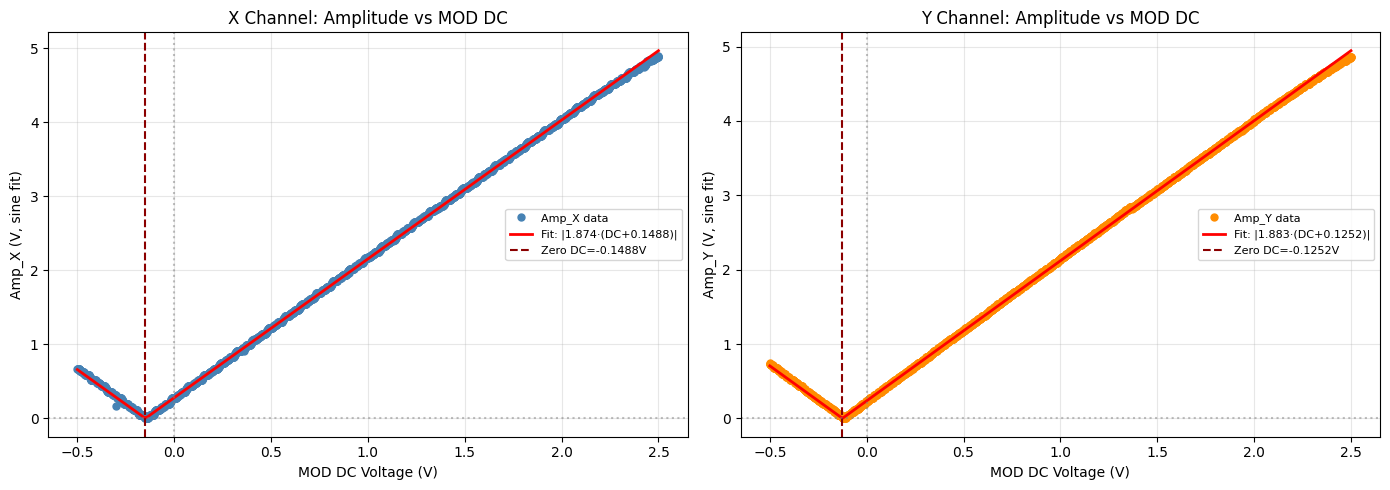

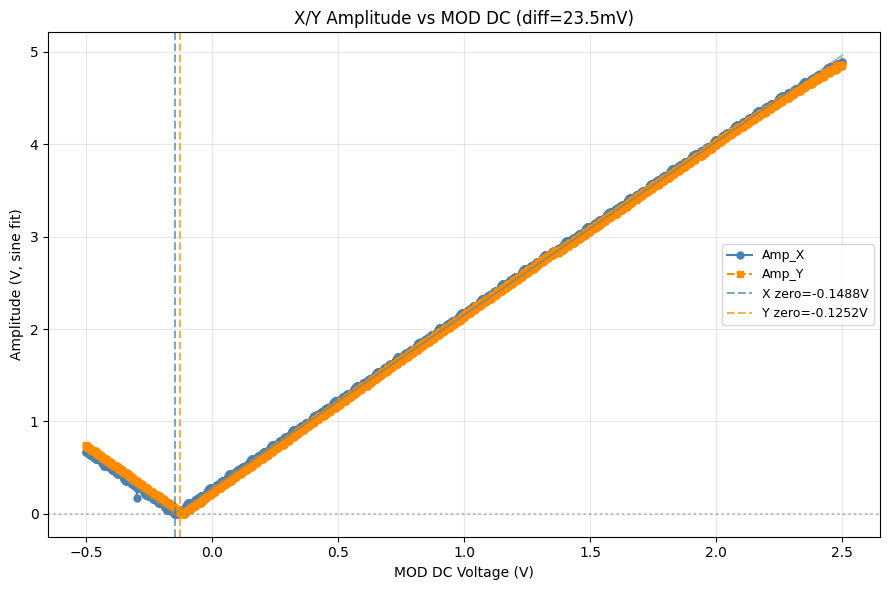


零输出偏置测量结果:
  X 通道: DC_offset = -0.1488 V
  Y 通道: DC_offset = -0.1252 V
  偏置差异 = 23.5 mV
  => MOD_OFFSET_Y 推荐值 = -23.5 mV

✅ 零输出偏置测量完成!
  结果已保存: d:\Code\exp_agent\data\XY_MOD_ZeroOffset\0522_1253_zero_offset\results


In [19]:
# ============================================================
# 可视化: Amp vs DC + |k·(x+b)| 拟合 + 零输出点
# ============================================================

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

# ---- (a) Amp_X vs DC ----
axes1[0].plot(DC_VALS, amp_x, "o", ms=5, color="steelblue", label="Amp_X data")
dc_fit = np.linspace(DC_SCAN_MIN, DC_SCAN_MAX, 200)
axes1[0].plot(dc_fit, abs_linear(dc_fit, k_x, b_x), "-", lw=2, color="red",
              label=f"Fit: |{k_x:.3f}·(DC{b_x:+.4f})|")
axes1[0].axvline(x=zero_dc_x, color="darkred", ls="--", lw=1.5,
                 label=f"Zero DC={zero_dc_x:.4f}V")
axes1[0].axvline(x=0, color="gray", ls=":", alpha=0.5)
axes1[0].axhline(y=0, color="gray", ls=":", alpha=0.5)
axes1[0].set_xlabel("MOD DC Voltage (V)")
axes1[0].set_ylabel("Amp_X (V, sine fit)")
axes1[0].set_title("X Channel: Amplitude vs MOD DC")
axes1[0].legend(fontsize=8); axes1[0].grid(True, alpha=0.3)

# ---- (b) Amp_Y vs DC ----
axes1[1].plot(DC_VALS, amp_y, "o", ms=5, color="darkorange", label="Amp_Y data")
axes1[1].plot(dc_fit, abs_linear(dc_fit, k_y, b_y), "-", lw=2, color="red",
              label=f"Fit: |{k_y:.3f}·(DC{b_y:+.4f})|")
axes1[1].axvline(x=zero_dc_y, color="darkred", ls="--", lw=1.5,
                 label=f"Zero DC={zero_dc_y:.4f}V")
axes1[1].axvline(x=0, color="gray", ls=":", alpha=0.5)
axes1[1].axhline(y=0, color="gray", ls=":", alpha=0.5)
axes1[1].set_xlabel("MOD DC Voltage (V)")
axes1[1].set_ylabel("Amp_Y (V, sine fit)")
axes1[1].set_title("Y Channel: Amplitude vs MOD DC")
axes1[1].legend(fontsize=8); axes1[1].grid(True, alpha=0.3)

plt.tight_layout()
display(fig1)
fig1.savefig(results_dir / "zero_offset_fit.png", dpi=150)
plt.close(fig1)

# ---- (c) X/Y 叠加对比 ----
fig2, ax2 = plt.subplots(figsize=(9, 6))
ax2.plot(DC_VALS, amp_x, "o-", ms=5, color="steelblue", label="Amp_X")
ax2.plot(DC_VALS, amp_y, "s--", ms=5, color="darkorange", label="Amp_Y")
ax2.plot(dc_fit, abs_linear(dc_fit, k_x, b_x), "-", lw=1.5, color="steelblue", alpha=0.5)
ax2.plot(dc_fit, abs_linear(dc_fit, k_y, b_y), "--", lw=1.5, color="darkorange", alpha=0.5)
ax2.axvline(x=zero_dc_x, color="steelblue", ls="--", alpha=0.7,
            label=f"X zero={zero_dc_x:.4f}V")
ax2.axvline(x=zero_dc_y, color="darkorange", ls="--", alpha=0.7,
            label=f"Y zero={zero_dc_y:.4f}V")
ax2.axhline(y=0, color="gray", ls=":", alpha=0.5)
ax2.set_xlabel("MOD DC Voltage (V)")
ax2.set_ylabel("Amplitude (V, sine fit)")
ax2.set_title(f"X/Y Amplitude vs MOD DC (diff={abs(zero_dc_x-zero_dc_y)*1000:.1f}mV)")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
plt.tight_layout()
display(fig2)
fig2.savefig(results_dir / "xy_comparison.png", dpi=150)
plt.close(fig2)

# ---- 统计输出 ----
print(f"\n零输出偏置测量结果:")
print(f"  X 通道: DC_offset = {zero_dc_x:.4f} V")
print(f"  Y 通道: DC_offset = {zero_dc_y:.4f} V")
print(f"  偏置差异 = {abs(zero_dc_x - zero_dc_y)*1000:.1f} mV")
print(f"  => MOD_OFFSET_Y 推荐值 = {-(zero_dc_y - zero_dc_x)*1000:.1f} mV")
print(f"\n✅ 零输出偏置测量完成!")
print(f"  结果已保存: {results_dir}")

<a id='cleanup'></a>
## 6. 安全关闭

In [20]:
# ---- 断开所有设备（保持输出状态不变） ----

print("正在断开设备...")

# dg_am: 先关闭输出
if hasattr(dg_am, "set_output"):
    dg_am.set_output(False, channel=1)
    dg_am.set_output(False, channel=2)
    print("  dg_am: 输出 OFF")

for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name}: 已断开")
        except Exception as e:
            print(f"  {name}: {e}")

print("所有设备已断开")

正在断开设备...
  dg_am: 输出 OFF
  dg_comp: 已断开
  dg_sweep: 已断开
  dg_mod: 已断开
  dg_temp: 已断开
  dg_laser: 已断开
  hf2: 已断开
  dg_am: 已断开
  scope: 已断开
所有设备已断开
